In [1]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("../database/student.db")

query = "SELECT * FROM students"

df = pd.read_sql(query, conn)

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [ ]:
###Top 10 Performing Students
# import sqlite3
import pandas as pd

# Database se connect karo
conn = sqlite3.connect("../Database/student.db")

# SQL query
query = """
SELECT *
FROM students
ORDER BY G3 DESC
LIMIT 10;
"""

# Query run karo aur result DataFrame mein store karo
top_students = pd.read_sql(query, conn)

# Output dikhao
top_students

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,M,16,U,GT3,T,4,3,health,services,...,4,2,2,1,1,2,4,19,19,20
1,GP,M,15,U,LE3,A,3,2,services,other,...,4,2,2,1,1,1,0,16,18,19
2,GP,M,15,U,LE3,A,4,4,teacher,teacher,...,5,5,3,1,1,4,6,18,19,19
3,GP,M,15,U,LE3,T,4,2,teacher,other,...,3,5,2,1,1,3,10,18,19,19
4,GP,F,18,U,GT3,T,2,2,at_home,at_home,...,4,3,3,1,2,2,5,18,18,19
5,MS,F,18,R,LE3,T,4,4,other,other,...,5,4,4,1,1,1,0,19,18,19
6,GP,M,15,U,LE3,T,4,3,teacher,services,...,5,4,3,1,1,4,2,15,16,18
7,GP,M,15,U,GT3,T,4,4,services,teacher,...,4,3,3,1,1,5,2,19,18,18
8,GP,F,15,U,GT3,T,4,3,services,other,...,4,5,5,1,3,1,4,16,17,18
9,GP,M,15,U,GT3,A,3,4,services,other,...,5,4,4,1,1,1,0,16,18,18


In [3]:
###Attendance vs Performance Analysis
import sqlite3
import pandas as pd

conn = sqlite3.connect("../Database/student.db")
query = """
SELECT absences, AVG(G3) AS avg_marks
FROM students
GROUP BY absences
ORDER BY absences;
"""

result = pd.read_sql_query(query, conn)
result.head()

,absences,avg_marks
0,0,8.443478
1,1,13.000000
2,2,11.907692
3,3,11.500000
4,4,11.283019


Matplotlib is building the font cache; this may take a moment.


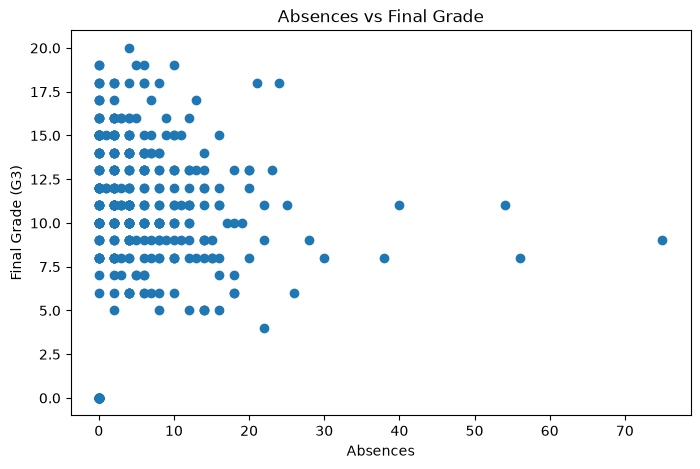

In [4]:
import matplotlib.pyplot as plt
df = pd.read_csv("../Data/student_data.csv")
df = pd.read_sql_query("SELECT * FROM students", conn)
plt.figure(figsize=(8,5))

plt.scatter(df["absences"], df["G3"])

plt.xlabel("Absences")
plt.ylabel("Final Grade (G3)")
plt.title("Absences vs Final Grade")

plt.show()

In [6]:
###Study Time Impact
import sqlite3
import pandas as pd
conn = sqlite3.connect("../Database/student.db")
query = """
SELECT studytime, AVG(G3) AS avg_grade
FROM students
GROUP BY studytime;
"""

result = pd.read_sql_query(query, conn)
result

,studytime,avg_grade
0,1,10.047619
1,2,10.171717
2,3,11.400000
3,4,11.259259


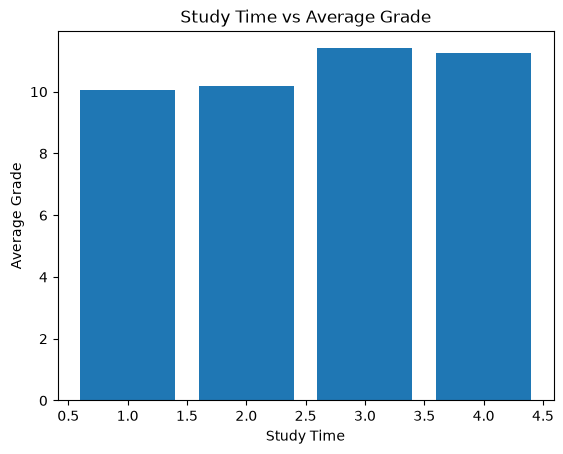

In [7]:
import matplotlib.pyplot as plt

plt.bar(result["studytime"], result["avg_grade"])
plt.xlabel("Study Time")
plt.ylabel("Average Grade")
plt.title("Study Time vs Average Grade")
plt.show()

In [10]:
###Failure Analysis
import sqlite3
import pandas as pd
conn = sqlite3.connect("../Database/student.db")
query = """
SELECT failures, AVG(G3) AS avg_grade
FROM students
GROUP BY failures;
"""

result = pd.read_sql_query(query, conn)
result

,failures,avg_grade
0,0,11.253205
1,1,8.120000
2,2,6.235294
3,3,5.687500


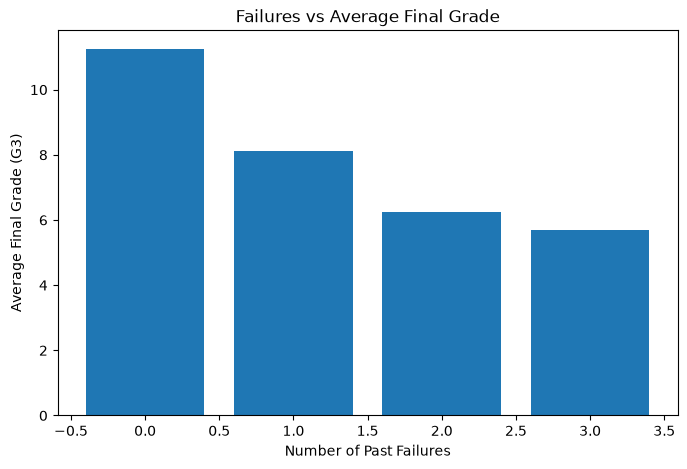

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(result["failures"], result["avg_grade"])

plt.xlabel("Number of Past Failures")
plt.ylabel("Average Final Grade (G3)")
plt.title("Failures vs Average Final Grade")

plt.show()

In [12]:
###Gender-wise Performance
query = """
SELECT sex, AVG(G3) AS avg_grade
FROM students
GROUP BY sex;
"""

result = pd.read_sql_query(query, conn)
result

,sex,avg_grade
0,F,9.966346
1,M,10.914439


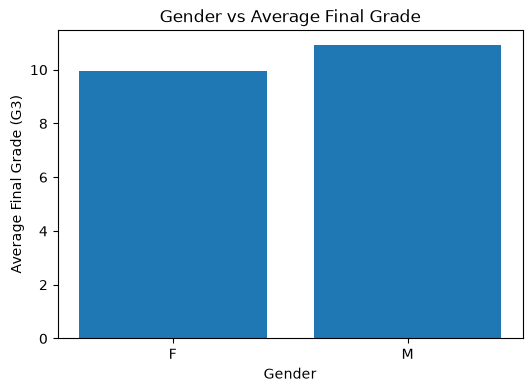

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(result["sex"], result["avg_grade"])

plt.xlabel("Gender")
plt.ylabel("Average Final Grade (G3)")
plt.title("Gender vs Average Final Grade")

plt.show()

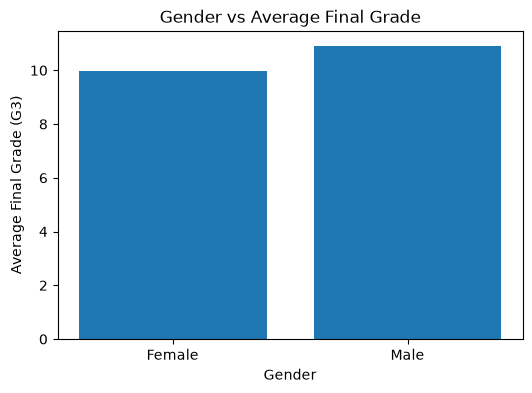

In [14]:
result["sex"] = result["sex"].replace({
    "F": "Female",
    "M": "Male"
})

plt.figure(figsize=(6,4))
plt.bar(result["sex"], result["avg_grade"])
plt.xlabel("Gender")
plt.ylabel("Average Final Grade (G3)")
plt.title("Gender vs Average Final Grade")
plt.show()

In [15]:
###Parents Education Impact
query = """
SELECT Medu, AVG(G3) AS avg_grade
FROM students
GROUP BY Medu;
"""

result = pd.read_sql_query(query, conn)
result

,Medu,avg_grade
0,0,13.000000
1,1,8.677966
2,2,9.728155
3,3,10.303030
4,4,11.763359


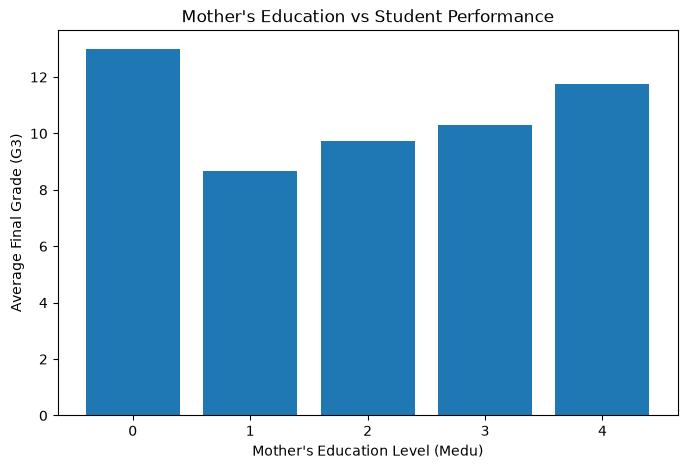

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(result["Medu"], result["avg_grade"])

plt.xlabel("Mother's Education Level (Medu)")
plt.ylabel("Average Final Grade (G3)")
plt.title("Mother's Education vs Student Performance")

plt.show()

In [2]:
import pandas as pd
import sqlite3

conn = sqlite3.connect("../database/student.db")  
query = """
SELECT internet, AVG(G3) AS avg_grade
FROM students
GROUP BY internet;
"""

result = pd.read_sql_query(query, conn)
result

,internet,avg_grade
0,no,9.409091
1,yes,10.617021


In [2]:
###Alcohol Consumption Impact
import pandas as pd
import sqlite3

conn = sqlite3.connect("../database/student.db") 
query = """
SELECT Walc, AVG(G3) AS avg_grade
FROM students
GROUP BY Walc;
"""

result = pd.read_sql_query(query, conn)
result

,Walc,avg_grade
0,1,10.735099
1,2,10.082353
2,3,10.725000
3,4,9.686275
4,5,10.142857


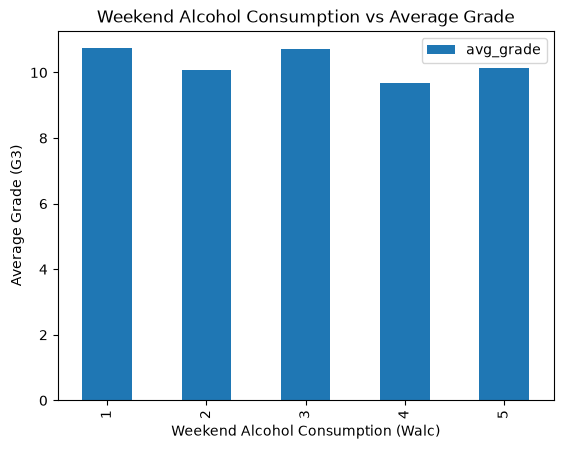

In [3]:
import matplotlib.pyplot as plt

query = """
SELECT Walc, AVG(G3) AS avg_grade
FROM students
GROUP BY Walc;
"""

result = pd.read_sql_query(query, conn)

result.plot(
    x="Walc",
    y="avg_grade",
    kind="bar"
)

plt.title("Weekend Alcohol Consumption vs Average Grade")
plt.xlabel("Weekend Alcohol Consumption (Walc)")
plt.ylabel("Average Grade (G3)")
plt.show()

In [4]:
###Risk Detection
query = """
SELECT *
FROM students
WHERE G3 < 10
   OR failures > 0
   OR absences > 10;
"""

result = pd.read_sql_query(query, conn)
result

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,17,U,GT3,A,4,4,other,teacher,...,4,1,4,1,1,1,6,6,5,6
4,GP,F,15,U,GT3,T,4,4,teacher,health,...,3,3,3,1,2,2,0,10,8,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180,MS,F,18,U,LE3,T,3,1,teacher,services,...,4,3,4,1,1,1,0,7,9,8
181,MS,F,18,U,GT3,T,1,1,other,other,...,1,1,1,1,1,5,0,6,5,0
182,MS,M,20,U,LE3,A,2,2,services,services,...,5,5,4,4,5,4,11,9,9,9
183,MS,M,21,R,GT3,T,1,1,other,other,...,5,5,3,3,3,3,3,10,8,7


In [5]:
###only for important columns
query = """
SELECT school, sex, age, failures, absences, G3
FROM students
WHERE G3 < 10
   OR failures > 0
   OR absences > 10;
"""

result = pd.read_sql_query(query, conn)
result

,school,sex,age,failures,absences,G3
0,GP,F,18,0,6,6
1,GP,F,17,0,4,6
2,GP,F,15,3,10,10
3,GP,F,17,0,6,6
4,GP,F,15,0,0,9
...,...,...,...,...,...,...
180,MS,F,18,0,0,8
181,MS,F,18,1,0,0
182,MS,M,20,2,11,9
183,MS,M,21,3,3,7


In [6]:
### student count only
query = """
SELECT COUNT(*) AS at_risk_students
FROM students
WHERE G3 < 10
   OR failures > 0
   OR absences > 10;
"""

result = pd.read_sql_query(query, conn)
result

,at_risk_students
0,185


In [7]:
###School-wise Comparison
query = """
SELECT school, AVG(G3) AS avg_grade
FROM students
GROUP BY school;
"""

result = pd.read_sql_query(query, conn)
result

,school,avg_grade
0,GP,10.489971
1,MS,9.847826


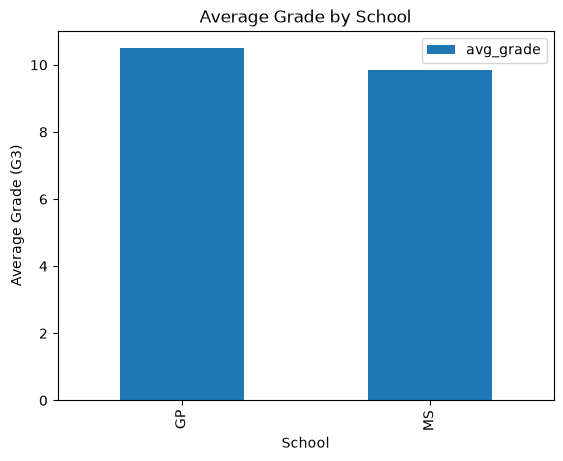

In [8]:
import matplotlib.pyplot as plt

query = """
SELECT school, AVG(G3) AS avg_grade
FROM students
GROUP BY school;
"""

result = pd.read_sql_query(query, conn)

result.plot(
    x="school",
    y="avg_grade",
    kind="bar"
)

plt.title("Average Grade by School")
plt.xlabel("School")
plt.ylabel("Average Grade (G3)")
plt.show()